In [1]:
import os
import sys
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MultiLabelBinarizer
from evaluation import evaluate_multilabel_model
from torch.utils.data import DataLoader, Dataset
from pathlib import Path

In [2]:
#Paths to CSVs
BASE_DIR = r"C:\Users\Anish Parmar\Downloads\NLP_Project\imdb_cleaned_data"

TRAIN_CSV = os.path.join(BASE_DIR, "imdb_arh_train.csv")
VAL_CSV   = os.path.join(BASE_DIR, "imdb_arh_val.csv")
TEST_CSV  = os.path.join(BASE_DIR, "imdb_arh_test.csv")

In [3]:
class IMDBDataset(Dataset):
    def __init__(self, data_dir_path, filename, class_names, text_col='description', label_col='genre_list'):
        """
        Args:
            data_dir_path (Path or str): Relative path to data directory.
            filename (str): The CSV filename (e.g., 'train.csv').
            class_names (list): List of valid classes (ORDER MATTERS).
            text_col (str): Column name for text.
            label_col (str): Column name for labels.
        """
        # 1. Setup Path safely
        self.data_path = Path(data_dir_path) / filename
        
        if not self.data_path.exists():
            raise FileNotFoundError(f"File not found at: {self.data_path.resolve()}")
            
        print(f"Loading data from {self.data_path.name}...")
        self.df = pd.read_csv(self.data_path)
        
        # 2. Process Text (Handle NaNs, ensure strings)
        self.texts = self.df[text_col].fillna("").astype(str).tolist()
        
        # 3. Process Labels (Multi-hot Encoding)
        # Create map: "Action" -> 0, "Drama" -> 1, etc.
        self.class_to_idx = {cls: i for i, cls in enumerate(class_names)}
        self.num_classes = len(class_names)
        self.labels = []
        
        # Track unseen genres for safety warning
        unseen_genres = set()
        
        for genre_str in self.df[label_col]:
            # Initialize zero vector [0.0, 0.0, ...]
            label_vec = torch.zeros(self.num_classes, dtype=torch.float)

            if pd.notna(genre_str):
                # Split "Action, Drama" -> ["Action", "Drama"]
                # .strip() removes whitespace around words
                current_genres = [g.strip() for g in str(genre_str).split(',')]
                
                for genre in current_genres:
                    if genre in self.class_to_idx:
                        idx = self.class_to_idx[genre]
                        label_vec[idx] = 1.0
                    else:
                        # Track genres that don't match our class list
                        unseen_genres.add(genre)
            
            self.labels.append(label_vec)

        # 4. Warning System
        # If this is the test set, and it has weird genres not in train, warn the user.
        if unseen_genres:
            print(f"⚠️  WARNING in {filename}: Found {len(unseen_genres)} genres not in the provided class list.")
            print(f"   Examples of ignored genres: {list(unseen_genres)[:5]}")
            print(f"   (These were ignored during label creation)")

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

    @staticmethod
    def discover_classes(data_dir_path, filename, label_col='genre_list'):
        """
        Static utility to scan a CSV and return sorted unique class names.
        Use this ONCE on your TRAINING set only.
        """
        path = Path(data_dir_path) / filename
        if not path.exists():
             raise FileNotFoundError(f"File not found at: {path.resolve()}")

        df = pd.read_csv(path)

        # Split by comma, explode list to rows, strip whitespace, find unique
        genres = df[label_col].dropna().astype(str).str.split(',').explode().str.strip().unique()
        
        return sorted(list(genres))

In [4]:
def load_multilabel_for_lstm(data_dir_path, filename, class_names,
                           text_col="description", label_col="genre_list"):
    """
    Use the same preprocessing as IMDBDataset, but return:
      texts_raw:    list[str]
      label_sets:   list[set[str]]  (e.g. {'Action','Drama'})
    """
    path = Path(data_dir_path) / filename
    if not path.exists():
        raise FileNotFoundError(f"File not found at: {path.resolve()}")

    df = pd.read_csv(path)

    texts_raw = df[text_col].fillna("").astype(str).tolist()

    label_sets = []
    for genre_str in df[label_col]:
        if pd.notna(genre_str):
            genres = [g.strip() for g in str(genre_str).split(",")]
            label_sets.append({g for g in genres if g in class_names})
        else:
            label_sets.append(set())

    return texts_raw, label_sets, df

In [5]:
DATA_DIR = "NLP_Project\imdb_cleaned_data"

class_names = IMDBDataset.discover_classes(DATA_DIR, TRAIN_CSV, label_col="genre_list")

print(class_names)

<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Anish Parmar\AppData\Local\Temp\ipykernel_17936\3109323730.py:1: SyntaxWarning: invalid escape sequence '\i'
  DATA_DIR = "NLP_Project\imdb_cleaned_data"


['Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Talk-Show', 'Thriller', 'War', 'Western']


In [6]:
X_train_raw, Y_train_sets, df_train = load_multilabel_for_lstm(DATA_DIR, TRAIN_CSV, class_names)
X_val_raw,   Y_val_sets,   df_val   = load_multilabel_for_lstm(DATA_DIR, VAL_CSV,   class_names)
X_test_raw,  Y_test_sets,  df_test  = load_multilabel_for_lstm(DATA_DIR, TEST_CSV,  class_names)


print(f"# train examples: {len(X_train_raw)}")
print(f"# val   examples: {len(X_val_raw)}")
print(f"# test  examples: {len(X_test_raw)}")

# train examples: 67772
# val   examples: 14523
# test  examples: 14523


In [7]:
def plot_multilabel_conf_matrix(model, X_raw, Y_true_sets, class_names, threshold=0.5):
    """
    Plot a 2x2 confusion matrix for each label in a multilabel problem.

    model        : your MultilabelNaiveBayes (must have predict_proba)
    X_raw        : list[str] raw descriptions
    Y_true_sets  : list[set/list] of true labels per example
    class_names  : list[str] in the same order used by the model
    threshold    : probability cutoff to convert to 0/1
    """

    # 1) Convert true sets -> binary matrix
    mlb = MultiLabelBinarizer(classes=class_names)
    Y_true_bin = mlb.fit_transform(Y_true_sets)   # shape [n_samples, n_labels]

    # 2) Predicted probabilities and binary predictions
    Y_pred_bin = model.predict(X_raw, threshold=threshold)

    # 3) One 2x2 confusion matrix per label
    mcm = multilabel_confusion_matrix(Y_true_bin, Y_pred_bin)

    for i, cls in enumerate(class_names):
        cm = mcm[i]

        fig, ax = plt.subplots(figsize=(4, 4))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=[f"not {cls}", cls],
        )
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"Confusion Matrix — {cls}")
        plt.tight_layout()
        plt.show()

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_val_seq   = tokenizer.texts_to_sequences(X_val_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN)
X_val   = pad_sequences(X_val_seq,   maxlen=MAX_LEN)
X_test  = pad_sequences(X_test_seq,  maxlen=MAX_LEN)

print("Tokenization complete.")
print(X_train.shape)

c:\Users\Anish Parmar\anaconda3\envs\p4ml\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Anish Parmar\anaconda3\envs\p4ml\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Anish Parmar\anaconda3\envs\p4ml\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.1 at tensorflow/core/framework/resource_handle.proto. Please update

Tokenization complete.
(67772, 200)


In [9]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer(classes=class_names)
mlb.fit(Y_train_sets)

Y_train = mlb.transform(Y_train_sets)
Y_val   = mlb.transform(Y_val_sets)
Y_test  = mlb.transform(Y_test_sets)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(len(class_names), activation='sigmoid')  # MULTI-LABEL
])

model.compile(
    loss='binary_crossentropy',  # MULTI-LABEL
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

c:\Users\Anish Parmar\anaconda3\envs\p4ml\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 854s 401ms/step - accuracy: 0.3973 - loss: 0.1850 - val_accuracy: 0.4771 - val_loss: 0.1583
Epoch 2/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 834s 387ms/step - accuracy: 0.4860 - loss: 0.1549 - val_accuracy: 0.4665 - val_loss: 0.1543
Epoch 3/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 850s 401ms/step - accuracy: 0.5039 - loss: 0.1457 - val_accuracy: 0.4829 - val_loss: 0.1533
Epoch 4/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 836s 395ms/step - accuracy: 0.5170 - loss: 0.1387 - val_accuracy: 0.4834 - val_loss: 0.1569
Epoch 5/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 838s 396ms/step - accuracy: 0.5271 - loss: 0.1325 - val_accuracy: 0.4739 - val_loss: 0.1611
Epoch 6/10
2118/2118 ━━━━━━━━━━━━━━━━━━━━ 840s 396ms/step - accuracy: 0.5366 - loss: 0.1261 - val_accuracy: 0.4737 - val_loss: 0.1643


In [12]:
# save model
model.save("saved_models/imdb_bilstm_multilabel_model_v1.keras")

In [16]:
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)  

454/454 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step


In [13]:
class KerasMultiLabelWrapper:
    def __init__(self, keras_model, threshold=0.5):
        self.model = keras_model
        self.threshold = threshold

    def predict(self, X_raw, threshold=None):
        # Use the threshold passed to predict if given, else default
        th = self.threshold if threshold is None else threshold

        # Tokenize + pad sequences exactly like training
        X_seq = tokenizer.texts_to_sequences(X_raw)
        X_pad = pad_sequences(X_seq, maxlen=MAX_LEN)

        # Predict probabilities
        y_proba = self.model.predict(X_pad, verbose=0)

        # Convert to binary using threshold
        return (y_proba >= th).astype(int)


In [14]:
wrapped_model = KerasMultiLabelWrapper(model)

In [15]:
print("\n=== Performance on VAL split ===")   

metrics = evaluate_multilabel_model(
    model=wrapped_model,
    X_raw=X_val_raw,
    Y_true_sets=Y_val_sets,
    label_names=class_names,
    mlb=mlb,
    threshold=0.5,
    average="micro",
    verbose=True,
)


=== Performance on VAL split ===
Multilabel overall performance
------------------------------------------------------------
Subset Accuracy:    0.2409
Precision (micro): 0.7450
Recall    (micro): 0.4339
F1        (micro): 0.5484
Jaccard (micro):    0.3778

Per-label metrics
------------------------------------------------------------
              precision    recall  f1-score   support

      Action       0.80      0.77      0.79      5312
       Adult       0.00      0.00      0.00         1
   Adventure       1.00      0.00      0.00      1242
   Animation       0.00      0.00      0.00       205
   Biography       0.00      0.00      0.00       123
      Comedy       0.00      0.00      0.00      3282
       Crime       0.00      0.00      0.00      1546
       Drama       0.57      0.48      0.52      5389
      Family       0.00      0.00      0.00       215
     Fantasy       0.00      0.00      0.00       584
   Film-Noir       0.00      0.00      0.00         6
   Game-Show 

In [16]:
print("\n=== Performance on TEST split ===")
test_metrics = evaluate_multilabel_model(
    model=wrapped_model,
    X_raw=X_test_raw,
    Y_true_sets=Y_test_sets,
    label_names=class_names,
    mlb=mlb,
    threshold=0.5,
    average="micro",
    verbose=True,
)


=== Performance on TEST split ===
Multilabel overall performance
------------------------------------------------------------
Subset Accuracy:    0.2440
Precision (micro): 0.7473
Recall    (micro): 0.4410
F1        (micro): 0.5546
Jaccard (micro):    0.3837

Per-label metrics
------------------------------------------------------------
              precision    recall  f1-score   support

      Action       0.81      0.76      0.78      5314
       Adult       0.00      0.00      0.00         1
   Adventure       0.50      0.00      0.00      1273
   Animation       0.00      0.00      0.00       178
   Biography       0.00      0.00      0.00       116
      Comedy       0.50      0.00      0.00      3284
       Crime       0.00      0.00      0.00      1422
       Drama       0.57      0.49      0.52      5499
      Family       0.00      0.00      0.00       199
     Fantasy       0.00      0.00      0.00       622
   Film-Noir       0.00      0.00      0.00         7
   Game-Show

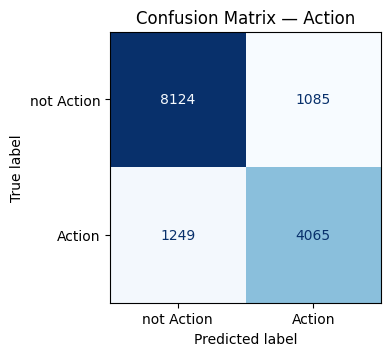

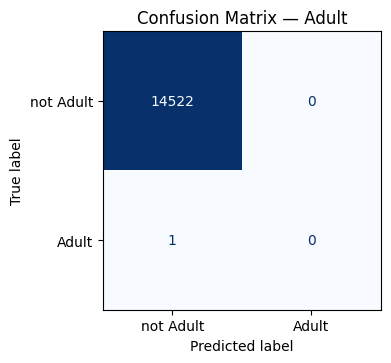

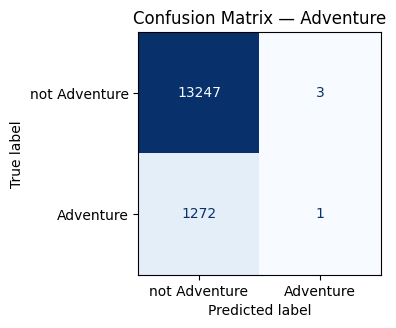

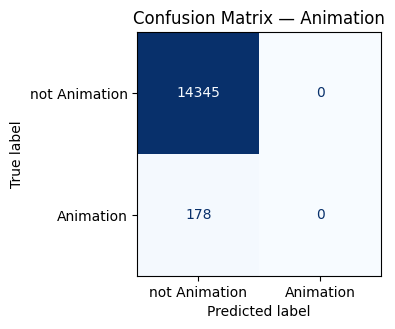

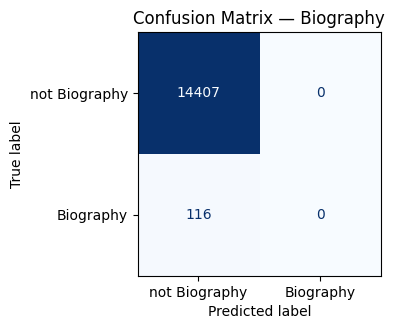

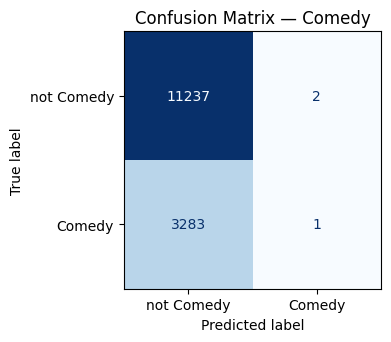

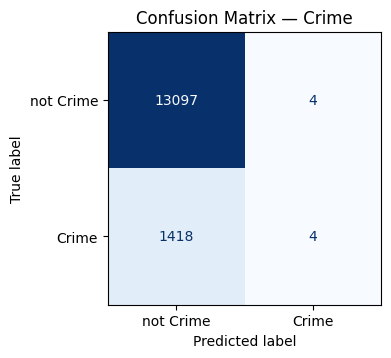

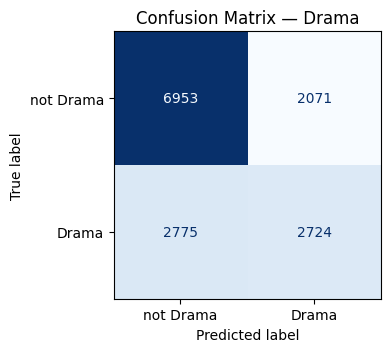

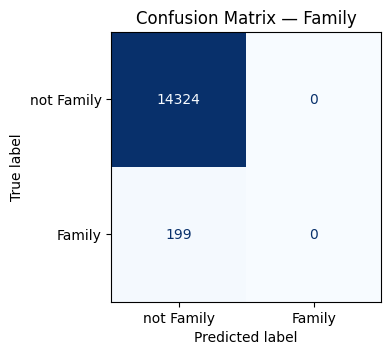

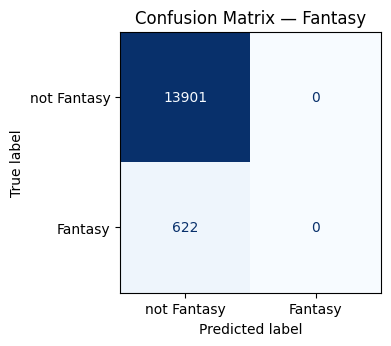

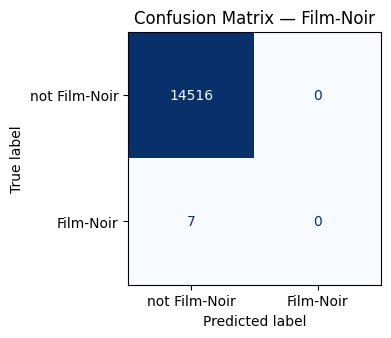

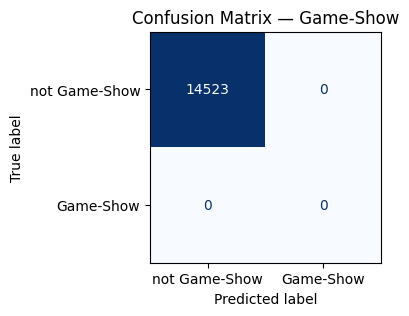

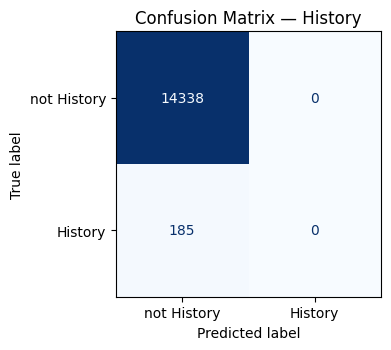

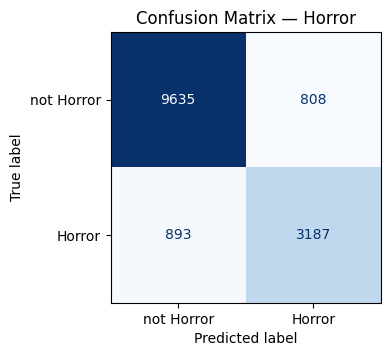

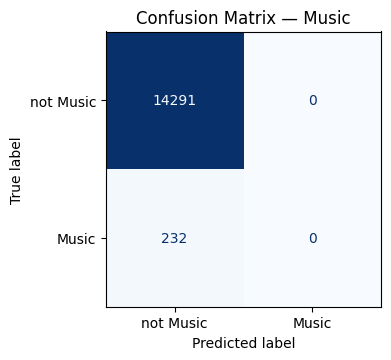

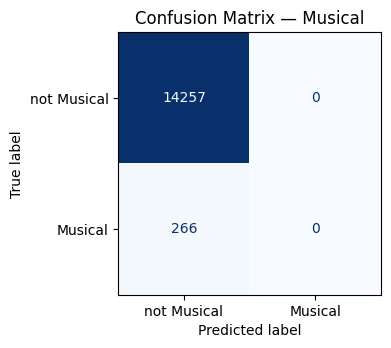

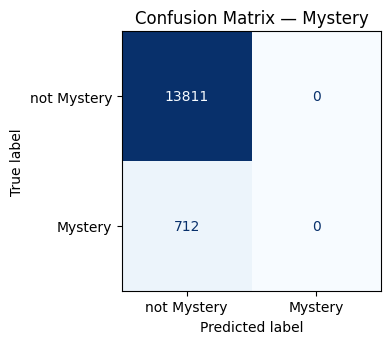

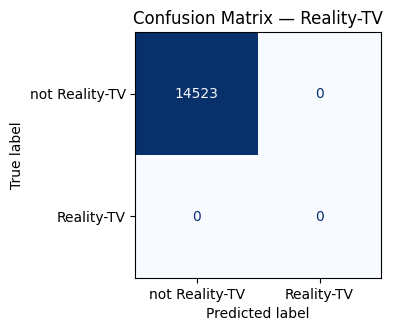

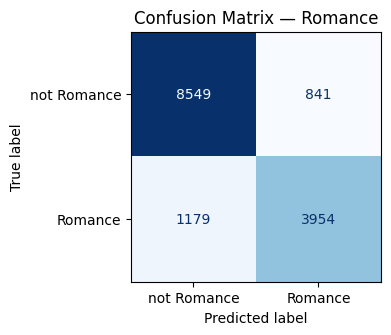

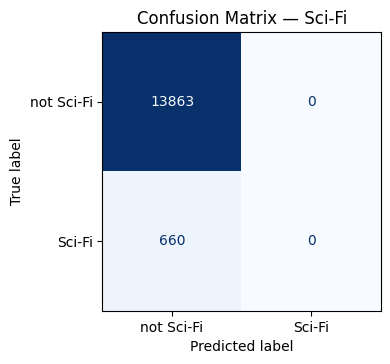

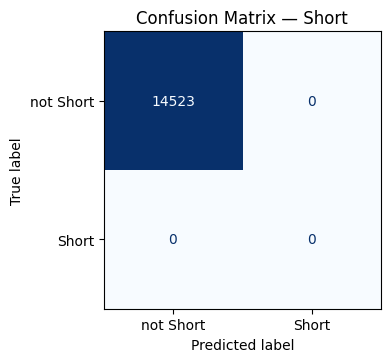

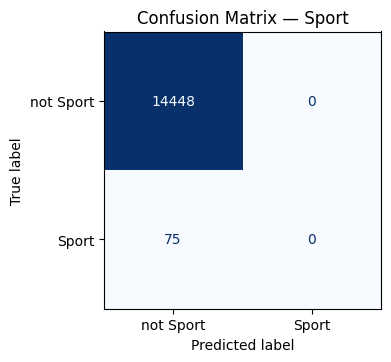

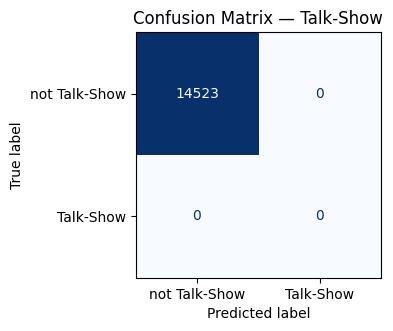

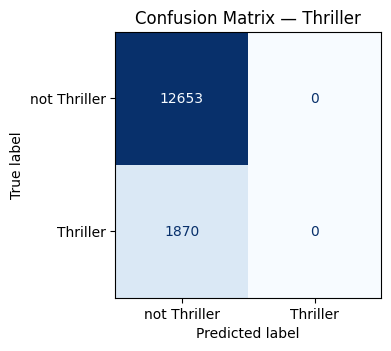

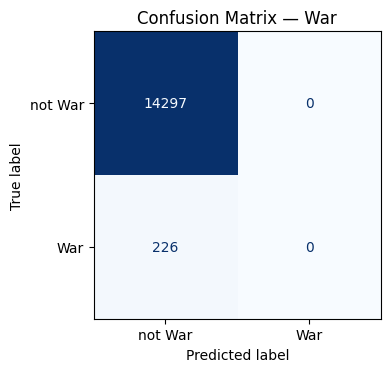

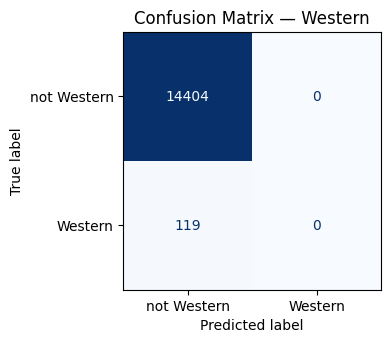

In [28]:
plot_multilabel_conf_matrix(wrapped_model, X_test_raw, Y_test_sets, class_names)